In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import matplotlib.dates as mdates
from scipy import stats
import ipynb.fs.full.eda as eda # type: ignore
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from tbats import TBATS

In [19]:
df = eda.load_and_prepare_data('taxi-dataset.parquet')

Loading data...

Dataset Shape: (3152677, 19)

Columns with missing values:
VendorID                     0
tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          93174
trip_distance                0
RatecodeID               93174
store_and_fwd_flag       93174
PULocationID                 0
DOLocationID                 0
payment_type                 0
fare_amount                  0
extra                        0
mta_tax                      0
tip_amount                   0
tolls_amount                 0
improvement_surcharge        0
total_amount                 0
congestion_surcharge     93174
airport_fee              93174
dtype: int64


In [20]:
df['fare_rate'] = df['fare_amount'] / df['trip_distance']
df['fare_rate'] = df['fare_rate'].replace([np.inf, -np.inf], np.nan).fillna(df['fare_rate'].median())
print(df.columns)

# Ensure data is sorted by datetime
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df = df.sort_values('tpep_pickup_datetime')

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'airport_fee', 'trip_duration',
       'pickup_hour', 'pickup_day', 'pickup_date', 'pickup_month',
       'pickup_year', 'pickup_dayofweek', 'tip_percentage',
       'payment_type_desc', 'trip_distance_filtered', 'fare_amount_filtered',
       'trip_duration_filtered', 'fare_rate'],
      dtype='object')


In [21]:
# Set pickup_datetime as index for time series analysis
df.set_index('tpep_pickup_datetime', inplace=True)

## Create different aggregations for time series analysis
# Daily average fare rate
daily_fare_rate = df.resample('D')['fare_rate'].mean()

# Hourly average fare rate
hourly_fare_rate = df.resample('H')['fare_rate'].mean()

# Weekly average fare rate
weekly_fare_rate = df.resample('W')['fare_rate'].mean()

# Monthly average fare rate
monthly_fare_rate = df.resample('M')['fare_rate'].mean()

In [22]:
def decompose_and_forecast_with_tbats(time_series, title, forecast_periods=None, seasonal_periods=None, 
                               plot_components=True, plot_forecast=True):
    """
    Decompose time series using TBATS and optionally forecast future values.
    
    Parameters:
    -----------
    time_series : pandas Series
        Time series data with datetime index
    title : str
        Title for the plots
    forecast_periods : int, optional
        Number of periods to forecast ahead, defaults to 10% of the series length
    seasonal_periods : list, optional
        List of seasonal periods to consider, e.g. [7, 365] for weekly and yearly seasonality
    plot_components : bool, optional
        Whether to plot the decomposition components
    plot_forecast : bool, optional
        Whether to plot the forecast
        
    Returns:
    --------
    tuple: (tbats_model, forecast, forecast_df)
        The fitted model, forecast array, and forecast dataframe
    """
    try:
        # Importing required libraries
        import numpy as np
        import pandas as pd
        import matplotlib.pyplot as plt
        import seaborn as sns
        from tbats import TBATS
        from datetime import timedelta
        
        # Print summary information about the time series
        print(f"\nAnalyzing {title} time series with TBATS")
        print(f"Time series length: {len(time_series)} data points")
        print(f"Time range: {time_series.index.min()} to {time_series.index.max()}")
        print(f"Value range: {time_series.min():.4f} to {time_series.max():.4f}")
        print(f"Standard deviation: {time_series.std():.4f}")
        
        # Check if there's enough data
        if len(time_series) < 4:
            print("Error: Not enough data points for TBATS modeling")
            return None, None, None
        
        # Determine forecast periods if not specified
        if forecast_periods is None:
            forecast_periods = max(int(len(time_series) * 0.1), 1)
            print(f"Automatically setting forecast periods to {forecast_periods}")
        
        # Set up seasonal periods intelligently if not specified
        if seasonal_periods is None:
            # Try to infer seasonality from the data frequency
            inferred_periods = []
            
            if isinstance(time_series.index, pd.DatetimeIndex):
                # Calculate approximate frequency
                if len(time_series) > 1:
                    avg_diff = (time_series.index[-1] - time_series.index[0]) / (len(time_series) - 1)
                    
                    # For daily data, suggest weekly seasonality
                    if timedelta(hours=20) <= avg_diff <= timedelta(hours=28):
                        inferred_periods.append(7)  # Weekly seasonality
                        if len(time_series) >= 365:
                            inferred_periods.append(365.25)  # Yearly seasonality
                    
                    # For hourly data, suggest daily seasonality
                    elif timedelta(minutes=45) <= avg_diff <= timedelta(hours=1.5):
                        inferred_periods.append(24)  # Daily seasonality
                        if len(time_series) >= 168:
                            inferred_periods.append(168)  # Weekly seasonality
                    
                    # For weekly data, suggest yearly seasonality
                    elif timedelta(days=5) <= avg_diff <= timedelta(days=9):
                        if len(time_series) >= 52:
                            inferred_periods.append(52)  # Yearly seasonality
                    
                    # For monthly data, suggest yearly seasonality
                    elif timedelta(days=25) <= avg_diff <= timedelta(days=35):
                        if len(time_series) >= 12:
                            inferred_periods.append(12)  # Yearly seasonality
            
            # If no seasonality detected, use default based on length
            if not inferred_periods and len(time_series) >= 7:
                if len(time_series) < 14:
                    inferred_periods = [7]  # Weekly
                else:
                    inferred_periods = [7]  # Weekly
                    if len(time_series) >= 90:
                        inferred_periods.append(30)  # Monthly
            
            seasonal_periods = inferred_periods
            
        # Print seasonality information
        if seasonal_periods and len(seasonal_periods) > 0:
            print(f"Using seasonal periods: {seasonal_periods}")
        else:
            print("No seasonal periods specified or detected")
        
        # Create and fit TBATS model
        print("\nFitting TBATS model... (this may take a while for larger datasets)")
        estimator = TBATS(
            seasonal_periods=seasonal_periods,
            use_arma_errors=True,  # Enable ARMA errors for better fitting
            use_box_cox=True,      # Try Box-Cox transformation to stabilize variance
            use_trend=True,        # Include trend component
            use_damped_trend=None, # Auto-detect if damped trend should be used
            show_warnings=False    # Suppress convergence warnings
        )
        
        # Convert series to numpy array for TBATS
        y = np.array(time_series)
        
        # Fit the model
        tbats_model = estimator.fit(y)
        
        # Get model parameters
        print("\nTBATS Model Information:")
        print(f"Box-Cox Transformation: {'Yes' if tbats_model.params.box_cox_lambda is not None else 'No'}")
        print(f"Trend Component: {'Yes' if tbats_model.params.trend_alpha > 0 else 'No'}")
        print(f"Damped Trend: {'Yes' if tbats_model.params.trend_damping_factor < 1 else 'No'}")
        print(f"ARMA Errors: {'Yes' if tbats_model.params.arma_order != (0, 0) else 'No'}")
        
        # Check which seasonal components were used
        print("Seasonal Components:")
        if tbats_model.params.seasonal_periods:
            for i, period in enumerate(tbats_model.params.seasonal_periods):
                print(f"  - Period {period}: {'Used' if tbats_model.params.seasonal_harmonics[i] > 0 else 'Not Used'}")
        else:
            print("  - No seasonal components")
        
        # Generate forecast
        forecast = tbats_model.forecast(steps=forecast_periods)
        
        # Create forecast dataframe with dates
        if isinstance(time_series.index, pd.DatetimeIndex):
            # Generate future dates
            last_date = time_series.index[-1]
            if len(time_series) > 1:
                freq = pd.infer_freq(time_series.index)
                if freq:
                    future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=forecast_periods, freq=freq)
                else:
                    # Estimate frequency from the last two points
                    delta = time_series.index[-1] - time_series.index[-2]
                    future_dates = [last_date + (i + 1) * delta for i in range(forecast_periods)]
            else:
                # If only one data point, assume daily frequency
                future_dates = [last_date + pd.Timedelta(days=i+1) for i in range(forecast_periods)]
                
            forecast_df = pd.DataFrame({
                'ds': future_dates,
                'yhat': forecast,
                'y': [None] * len(forecast)  # Placeholder for actual values (unknown)
            })
        else:
            # Non-datetime index
            last_idx = time_series.index[-1]
            if isinstance(last_idx, (int, float)):
                future_indices = [last_idx + i + 1 for i in range(forecast_periods)]
                forecast_df = pd.DataFrame({
                    'ds': future_indices,
                    'yhat': forecast,
                    'y': [None] * len(forecast)
                })
            else:
                # Other index types
                forecast_df = pd.DataFrame({
                    'ds': [f"{last_idx}+{i+1}" for i in range(forecast_periods)],
                    'yhat': forecast,
                    'y': [None] * len(forecast)
                })
        
        # Plot decomposition if requested
        if plot_components:
            components = tbats_model.components(y)
            labels = ['observed', 'level', 'slope'] + [f'seasonal_{i+1}' for i in range(len(tbats_model.params.seasonal_periods))]
            
            n_components = len(components)
            fig, axes = plt.subplots(n_components, 1, figsize=(14, 3 * n_components))
            
            # If only one component, wrap in list for consistent indexing
            if n_components == 1:
                axes = [axes]
                
            # Plot each component
            for i, (component, label) in enumerate(zip(components, labels)):
                # Create time axis
                if isinstance(time_series.index, pd.DatetimeIndex):
                    time_axis = time_series.index
                else:
                    time_axis = np.arange(len(time_series))
                    
                # Plot component
                if label == 'observed':
                    axes[i].plot(time_axis, component, 'b-', label=label)
                    axes[i].set_title(f"{title} - {label.capitalize()}")
                else:
                    axes[i].plot(time_axis, component, 'g-', label=label)
                    axes[i].set_title(f"{label.capitalize()} Component")
                    
                axes[i].grid(True)
                axes[i].legend()
                
            plt.tight_layout()
            plt.show()
        
        # Plot forecast if requested
        if plot_forecast:
            plt.figure(figsize=(14, 7))
            
            # Plot historical data
            if isinstance(time_series.index, pd.DatetimeIndex):
                plt.plot(time_series.index, time_series.values, 'b-', label='Historical Data')
                
                # Plot forecast
                future_dates = forecast_df['ds']
                plt.plot(future_dates, forecast, 'r-', label='TBATS Forecast')
                
                # Add confidence intervals (if available)
                if hasattr(tbats_model, 'forecast_intervals'):
                    try:
                        intervals = tbats_model.forecast_intervals(steps=forecast_periods, confidence=0.95)
                        plt.fill_between(future_dates, intervals[:, 0], intervals[:, 1], color='r', alpha=0.2, label='95% Confidence Interval')
                    except:
                        print("Note: Confidence intervals not available")
            else:
                # Non-datetime index
                plt.plot(time_series.values, 'b-', label='Historical Data')
                
                # Plot forecast with offset
                plt.plot(np.arange(len(time_series), len(time_series) + len(forecast)), forecast, 'r-', label='TBATS Forecast')
                
                # Add confidence intervals (if available)
                if hasattr(tbats_model, 'forecast_intervals'):
                    try:
                        intervals = tbats_model.forecast_intervals(steps=forecast_periods, confidence=0.95)
                        plt.fill_between(np.arange(len(time_series), len(time_series) + len(forecast)), 
                                         intervals[:, 0], intervals[:, 1], 
                                         color='r', alpha=0.2, label='95% Confidence Interval')
                    except:
                        print("Note: Confidence intervals not available")
                        
            plt.title(f"{title} - TBATS Forecast")
            plt.xlabel("Time")
            plt.ylabel(time_series.name if time_series.name else "Value")
            plt.grid(True)
            plt.legend()
            plt.tight_layout()
            plt.show()
        
        # Evaluate model performance
        mse = tbats_model.mse
        print(f"\nModel Performance:")
        print(f"Mean Squared Error (MSE): {mse:.4f}")
        print(f"Root Mean Squared Error (RMSE): {np.sqrt(mse):.4f}")
        print(f"AIC: {tbats_model.aic:.4f}")
        
        return tbats_model, forecast, forecast_df
    
    except Exception as e:
        print(f"Error in TBATS decomposition: {str(e)}")
        import traceback
        traceback.print_exc()
        return None, None, None

In [23]:
def decompose_and_forecast_with_tbats(time_series, title, forecast_periods=14, seasonal_periods=None):
    """
    Decompose time series using TBATS and generate forecasts
    
    Parameters:
    -----------
    time_series : array-like
        The time series data to analyze
    title : str
        Title for the plots
    forecast_periods : int, default=14
        Number of periods to forecast
    seasonal_periods : list, default=None
        List of seasonal periods to consider
        
    Returns:
    --------
    tbats_model : TBATS model
        The fitted TBATS model
    forecast : array
        The forecasted values
    forecast_df : pandas DataFrame
        DataFrame containing the forecast results
    """
    
    # Make sure there are no NaN values in the time series
    if isinstance(time_series, pd.Series):
        time_series = time_series.dropna()
    else:
        # Convert to numpy array if not already
        time_series = np.array(time_series)
        # Remove NaN values
        time_series = time_series[~np.isnan(time_series)]
    
    # Check if we have enough data after cleaning
    if len(time_series) < 2:
        print(f"Error: Insufficient data points after removing NaN values. Only {len(time_series)} valid points.")
        return None, None, None
    
    try:
        # Initialize and fit TBATS model
        estimator = TBATS(
            use_box_cox=True,  # Auto-determine if Box-Cox transformation should be used
            use_trend=True,    # Auto-determine if trend should be included
            use_damped_trend=True,  # Auto-determine if damped trend should be used
            seasonal_periods=seasonal_periods,
            use_arma_errors=True
        )
        
        # Fit model
        tbats_model = estimator.fit(time_series)
        
        # Print model components information
        print(f"\nTBATS Model Information:")
        print(f"Box-Cox Transformation: {'Yes' if tbats_model.params.box_cox_lambda is not None else 'No'}")
        
        # Try to access component information safely
        try:
            # Access model components safely using the appropriate attributes
            # These may vary depending on your tbats version
            components = tbats_model.params.components
            if hasattr(components, 'trend'):
                print(f"Trend Component: {'Yes' if components.trend else 'No'}")
                if hasattr(components, 'damping_parameter'):
                    print(f"Damped Trend: {'Yes' if components.damping_parameter < 1 else 'No'}")
            else:
                # Alternative way to check if trend exists
                print(f"Trend Component: {'Yes' if hasattr(tbats_model.params, 'trend') else 'No'}")
                
            # Print seasonal periods if any
            if hasattr(tbats_model.params, 'seasonal_periods') and tbats_model.params.seasonal_periods:
                print(f"Seasonal Periods: {tbats_model.params.seasonal_periods}")
            else:
                print("Seasonal Periods: None")
                
            # Print ARMA orders if any
            if hasattr(tbats_model.params, 'p') and hasattr(tbats_model.params, 'q'):
                print(f"ARMA Orders: p={tbats_model.params.p}, q={tbats_model.params.q}")
                
        except AttributeError as e:
            print(f"Error in accessing model components: {str(e)}")
            # Continue with forecasting despite the error
        
        # Generate forecast
        forecast = tbats_model.forecast(steps=forecast_periods)
        
        # Create a DataFrame for the forecast results
        forecast_index = pd.RangeIndex(start=len(time_series), stop=len(time_series) + forecast_periods)
        forecast_df = pd.DataFrame({
            'forecast': forecast
        }, index=forecast_index)
        
        # Plot the original series and forecast
        plt.figure(figsize=(12, 6))
        
        # Plot original data
        plt.plot(np.arange(len(time_series)), time_series, label='Original', color='blue')
        
        # Plot forecast
        plt.plot(np.arange(len(time_series), len(time_series) + len(forecast)), 
                 forecast, label='Forecast', color='red', linestyle='--')
        
        plt.title(f'TBATS Forecast for {title}')
        plt.xlabel('Time')
        plt.ylabel('Value')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()
        
        return tbats_model, forecast, forecast_df
    
    except Exception as e:
        print(f"Error in TBATS decomposition: {str(e)}")
        return None, None, None

In [24]:
# def time_series_decomposition(df):
#     """
#     Perform time series decomposition and analysis on fare rate data
    
#     Parameters:
#     -----------
#     df : pandas DataFrame
#         DataFrame with trip data
#     """
#     try:
#         print("\nPerforming time series decomposition analysis...")
        
#         # Make sure required libraries are installed
#         try:
#             from tbats import TBATS
#         except ImportError:
#             print("TBATS library not found. Installing...")
#             import sys
#             import subprocess
#             subprocess.check_call([sys.executable, "-m", "pip", "install", "tbats"])
#             from tbats import TBATS
        
#         from statsmodels.tsa.stattools import adfuller
        
#         # Create aggregated time series at different time scales
#         print("Creating time series aggregations at different time scales...")
        
#         # Daily aggregation
#         daily_fare_rate = df.groupby('pickup_date')['fare_rate'].mean()
#         daily_fare_rate.index = pd.to_datetime(daily_fare_rate.index)
#         daily_fare_rate = daily_fare_rate.sort_index()
        
#         # Hourly aggregation
#         df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
#         df['pickup_hour'] = df['pickup_datetime'].dt.floor('H')
#         hourly_fare_rate = df.groupby('pickup_hour')['fare_rate'].mean()
#         hourly_fare_rate = hourly_fare_rate.sort_index()
        
#         # Weekly aggregation
#         df['pickup_week'] = df['pickup_datetime'].dt.to_period('W').dt.start_time
#         weekly_fare_rate = df.groupby('pickup_week')['fare_rate'].mean()
#         weekly_fare_rate = weekly_fare_rate.sort_index()
        
#         # Monthly aggregation
#         df['pickup_month'] = df['pickup_datetime'].dt.to_period('M').dt.start_time
#         monthly_fare_rate = df.groupby('pickup_month')['fare_rate'].mean()
#         monthly_fare_rate = monthly_fare_rate.sort_index()
        
#         # Analysis by time period using TBATS
#         print("Decomposing fare rate time series using TBATS at different time scales...\n")
        
#         # Process each time series with TBATS
#         time_series_data = {
#             "Daily": (daily_fare_rate, [7, 30.4], "Daily Average Fare Rate"),
#             "Hourly": (hourly_fare_rate, [24, 168], "Hourly Average Fare Rate"),
#             "Weekly": (weekly_fare_rate, [52], "Weekly Average Fare Rate"),
#             "Monthly": (monthly_fare_rate, [12], "Monthly Average Fare Rate")
#         }
        
#         tbats_results = {}
        
#         for name, (ts, seasonal_periods, title) in time_series_data.items():
#             print(f"\n{'='*50}")
#             print(f"Processing {name} fare rate time series")
#             print(f"{'='*50}")
            
#             # Check if we have enough data
#             if len(ts) > 2:
#                 # Set appropriate forecast periods based on data length
#                 forecast_periods = min(int(len(ts) * 0.2) + 1, 14)
                
#                 # Skip seasonal periods if we don't have enough data
#                 if len(ts) <= max(seasonal_periods):
#                     seasonal_periods = None
                
#                 # Use TBATS for decomposition and forecasting
#                 tbats_model, forecast, forecast_df = decompose_and_forecast_with_tbats(
#                     ts, 
#                     title,
#                     forecast_periods=forecast_periods,
#                     seasonal_periods=seasonal_periods,
#                     plot_components=True,
#                     plot_forecast=True
#                 )
                
#                 # Store results
#                 tbats_results[name] = (tbats_model, forecast, forecast_df)
#             else:
#                 print(f"Insufficient data for {name} time series analysis (only {len(ts)} points)")
                
#         # Additional analysis: Fare rate by hour of day
#         if 'pickup_hour' in df.columns:
#             fare_by_hour = df.groupby(df['pickup_datetime'].dt.hour)['fare_rate'].mean()
            
#             plt.figure(figsize=(12, 6))
#             sns.barplot(x=fare_by_hour.index, y=fare_by_hour.values)
#             plt.title('Average Fare Rate by Hour of Day')
#             plt.xlabel('Hour of Day')
#             plt.ylabel('Average Fare Rate ($/mile)')
#             plt.xticks(range(0, 24))
#             plt.grid(True, axis='y')
#             plt.show()
        
#         # Fare rate vs. trip distance
#         if 'trip_distance' in df.columns and 'fare_rate' in df.columns:
#             plt.figure(figsize=(12, 6))
#             plt.scatter(df['trip_distance'], df['fare_rate'], alpha=0.3)
#             plt.title('Fare Rate vs. Trip Distance')
#             plt.xlabel('Trip Distance (miles)')
#             plt.ylabel('Fare Rate ($/mile)')
#             plt.grid(True)
#             plt.show()
        
#         print("\nTime series decomposition analysis complete!")
        
#         # Return results for potential further analysis
#         return {
#             'daily_fare_rate': daily_fare_rate,
#             'hourly_fare_rate': hourly_fare_rate,
#             'weekly_fare_rate': weekly_fare_rate,
#             'monthly_fare_rate': monthly_fare_rate,
#             'tbats_results': tbats_results
#         }
        
#     except Exception as e:
#         print(f"Error in time series decomposition: {str(e)}")
#         import traceback
#         traceback.print_exc()
#         return None


Performing TBATS analysis on fare rate time series...


Processing Daily fare rate time series

TBATS Model Information:
Box-Cox Transformation: Yes
Trend Component: No
Seasonal Periods: None


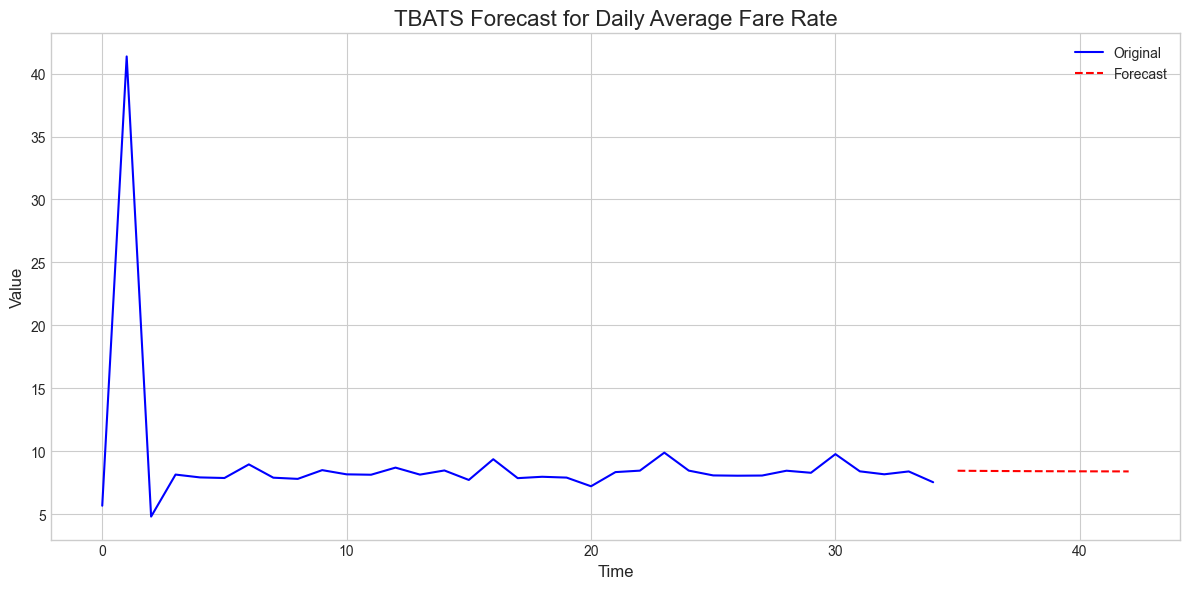


Processing Hourly fare rate time series

TBATS Model Information:
Box-Cox Transformation: Yes
Trend Component: No
Seasonal Periods: None


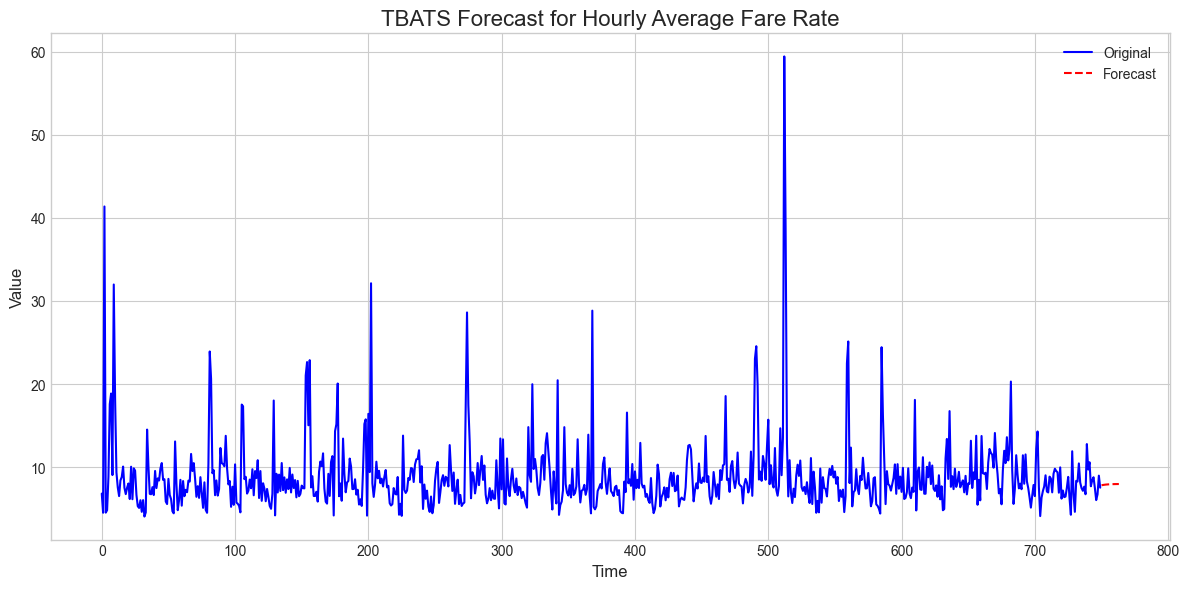


Processing Weekly fare rate time series

TBATS Model Information:
Box-Cox Transformation: Yes
Trend Component: No
Seasonal Periods: None


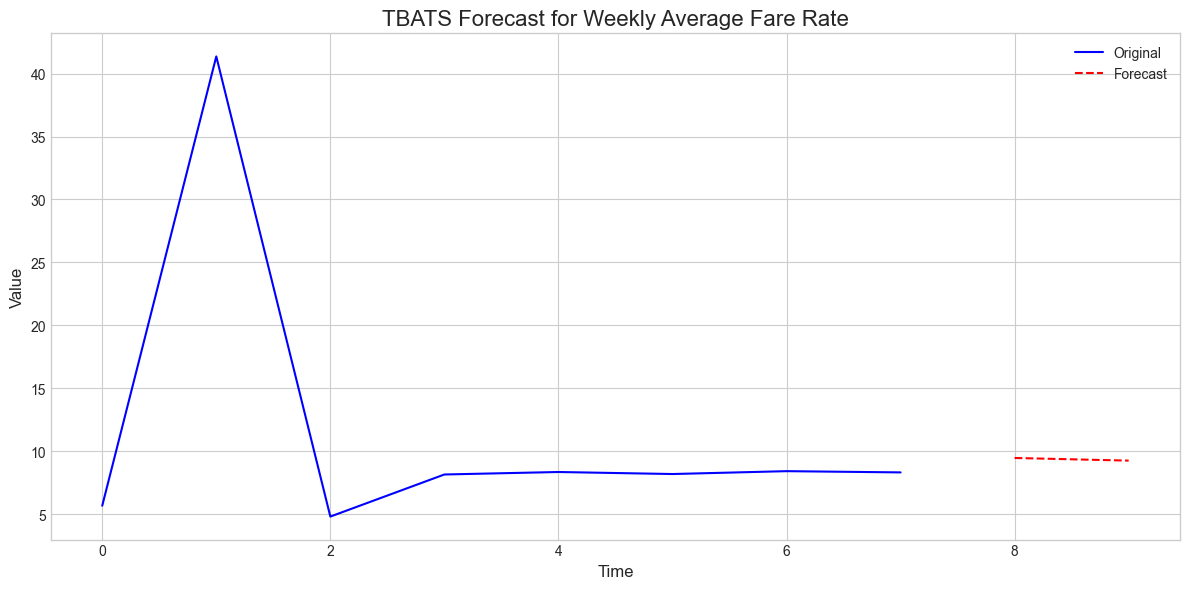


Processing Monthly fare rate time series

TBATS Model Information:
Box-Cox Transformation: Yes
Trend Component: No
Seasonal Periods: None


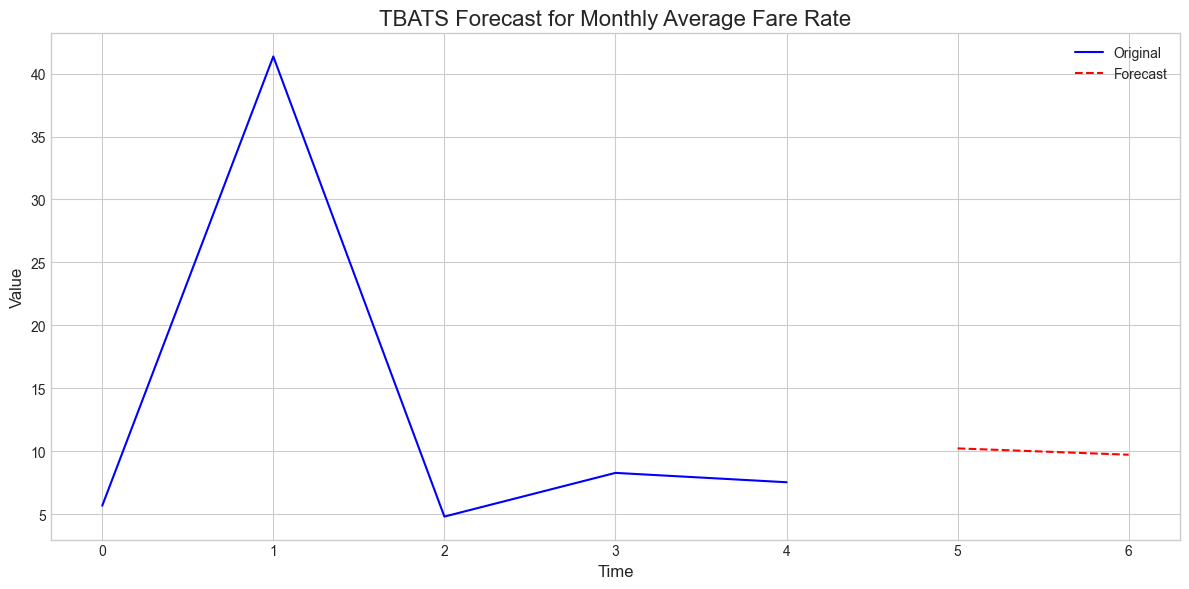


TBATS decomposition and forecasting complete!

Summary of forecasts:
Daily forecast: 8 periods ahead
  Range: 8.3922 to 8.4455
  Mean: 8.4131
  Last value: 8.3922
Hourly forecast: 14 periods ahead
  Range: 7.8231 to 7.9727
  Mean: 7.9272
  Last value: 7.9727
Weekly forecast: 2 periods ahead
  Range: 9.2500 to 9.4606
  Mean: 9.3553
  Last value: 9.2500
Monthly forecast: 2 periods ahead
  Range: 9.7185 to 10.2216
  Mean: 9.9700
  Last value: 9.7185


In [25]:
# Define our time series and appropriate seasonal periods
print("\nPerforming TBATS analysis on fare rate time series...\n")
time_series_data = {
    "Daily": (daily_fare_rate, [7, 30.4, 365.25]),           # Weekly and monthly seasonality
    "Hourly": (hourly_fare_rate, [24, 24*7, 24*30.4, 24*365.25]),         # Daily and weekly seasonality
    "Weekly": (weekly_fare_rate, [4.35, 52]),              # Yearly seasonality
    "Monthly": (monthly_fare_rate, [12])             # Yearly seasonality
}

# Process each time series
tbats_results = {}

for name, (ts, seasonal_periods) in time_series_data.items():

    ts = ts.dropna() if hasattr(ts, 'dropna') else ts[~np.isnan(ts)]
    
    print(f"\n{'='*50}")
    print(f"Processing {name} fare rate time series")
    print(f"{'='*50}")
    
    # Check if we have enough data
    if len(ts) > 2:
        # Set forecast periods - use shorter forecast for shorter series
        forecast_periods = min(int(len(ts) * 0.2) + 1, 14)
        
        # Use TBATS for decomposition and forecasting
        tbats_model, forecast, forecast_df = decompose_and_forecast_with_tbats(
            ts, 
            f"{name} Average Fare Rate",
            forecast_periods=forecast_periods,
            seasonal_periods=seasonal_periods if len(ts) > max(seasonal_periods) else None
        )
        
        # Store results
        tbats_results[name] = (tbats_model, forecast, forecast_df)
    else:
        print(f"Insufficient data for {name} time series analysis (only {len(ts)} points)")

print("\nTBATS decomposition and forecasting complete!")

# Optional: Compare forecasts from different time series
if len(tbats_results) > 0:
    print("\nSummary of forecasts:")
    for name, (model, forecast, forecast_df) in tbats_results.items():
        if forecast is not None:
            print(f"{name} forecast: {len(forecast)} periods ahead")
            print(f"  Range: {min(forecast):.4f} to {max(forecast):.4f}")
            print(f"  Mean: {np.mean(forecast):.4f}")
            print(f"  Last value: {forecast[-1]:.4f}")